In [38]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
default_setting_runs = [225]
simple_optimiser_runs = [1,91,102,104,128]

# load data
optimiser_history = (
    pl.read_csv("data/training-history.csv")
    .with_columns(iteration = pl.col("Target").cum_count())
    .with_columns(pl.when(pl.col("iteration").is_in(simple_optimiser_runs)).then(pl.lit("simple optimiser"))
                  .when(pl.col("iteration").is_in(default_setting_runs)).then(pl.lit("default 2025"))
                  .otherwise(pl.lit("optisation")).alias("steering"))
    .sort("Target")
)
print(optimiser_history)

shape: (225, 13)
┌─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ ELE ┆ ELE ┆ ELE ┆ ELENA_ ┆ ELENA ┆ ELENA ┆ ELENA ┆ ELENA ┆ ELENA ┆ ELENA ┆ Targe ┆ itera ┆ steer │
│ NA_ ┆ NA_ ┆ NA_ ┆ H1_COR ┆ _H2_C ┆ _H3_C ┆ _QD1_ ┆ _QF1_ ┆ _QD2_ ┆ _QF2_ ┆ t     ┆ tion  ┆ ing   │
│ V1_ ┆ V2_ ┆ V3_ ┆ RECTOR ┆ ORREC ┆ ORREC ┆ V     ┆ V     ┆ V     ┆ V     ┆ ---   ┆ ---   ┆ ---   │
│ COR ┆ COR ┆ COR ┆ _V     ┆ TOR_V ┆ TOR_V ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ f64   ┆ u32   ┆ str   │
│ REC ┆ REC ┆ REC ┆ ---    ┆ ---   ┆ ---   ┆ i64   ┆ i64   ┆ i64   ┆ i64   ┆       ┆       ┆       │
│ TOR ┆ TOR ┆ TOR ┆ i64    ┆ i64   ┆ i64   ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│ _V  ┆ _V  ┆ _V  ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│ --- ┆ --- ┆ --- ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│ i64 ┆ i64 ┆ i64 ┆        ┆       ┆       ┆       ┆       ┆       ┆      

In [46]:
pl.Config.set_tbl_cols(20)
print(optimiser_history.filter(pl.col("Target")==pl.col("Target").max()))

shape: (1, 13)
┌─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ ELE ┆ ELE ┆ ELE ┆ ELENA_ ┆ ELENA ┆ ELENA ┆ ELENA ┆ ELENA ┆ ELENA ┆ ELENA ┆ Targe ┆ itera ┆ steer │
│ NA_ ┆ NA_ ┆ NA_ ┆ H1_COR ┆ _H2_C ┆ _H3_C ┆ _QD1_ ┆ _QF1_ ┆ _QD2_ ┆ _QF2_ ┆ t     ┆ tion  ┆ ing   │
│ V1_ ┆ V2_ ┆ V3_ ┆ RECTOR ┆ ORREC ┆ ORREC ┆ V     ┆ V     ┆ V     ┆ V     ┆ ---   ┆ ---   ┆ ---   │
│ COR ┆ COR ┆ COR ┆ _V     ┆ TOR_V ┆ TOR_V ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ f64   ┆ u32   ┆ str   │
│ REC ┆ REC ┆ REC ┆ ---    ┆ ---   ┆ ---   ┆ i64   ┆ i64   ┆ i64   ┆ i64   ┆       ┆       ┆       │
│ TOR ┆ TOR ┆ TOR ┆ i64    ┆ i64   ┆ i64   ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│ _V  ┆ _V  ┆ _V  ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│ --- ┆ --- ┆ --- ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│ i64 ┆ i64 ┆ i64 ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆

In [98]:
palette="viridis"
norm = plt.Normalize(optimiser_history["Target"].min(), 1.05*optimiser_history["Target"].max()) # optimiser_history["Target"].min(), optimiser_history["Target"].max()
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

Text(0, 0.5, 'SC56_coinc*events_in_interval')

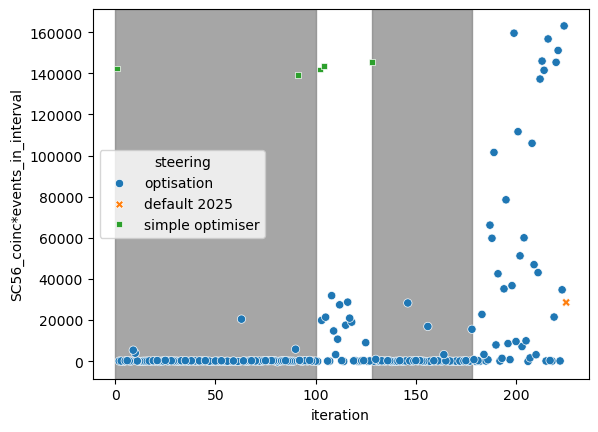

In [99]:
fig,ax = plt.subplots()

ax.axvspan(0,100,color='gray',alpha=0.7)
ax.axvspan(128,178,color='gray',alpha=0.7)
sns.scatterplot(optimiser_history,x="iteration",y="Target",hue='steering',style="steering",ax=ax)
ax.set_ylabel("SC56_coinc*events_in_interval")
# fig.colorbar(sm,ax[1],label="SC56_coinc*events_in_interval")

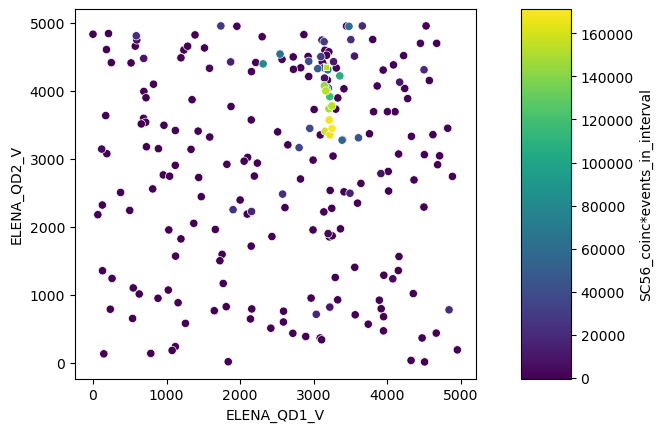

In [100]:
fig,ax = plt.subplots(1,2,width_ratios=(8,1))
sns.scatterplot(optimiser_history,x="ELENA_QD1_V",y="ELENA_QD2_V",hue="Target",palette=palette,style="steering",ax=ax[0],legend=False)

# Remove the legend and add a colorbar
fig.colorbar(sm,ax[1],label="SC56_coinc*events_in_interval")

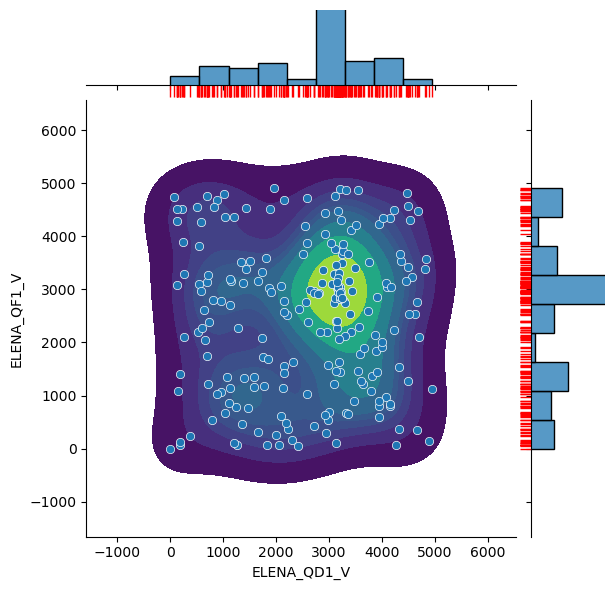

In [102]:
g = sns.jointplot(data=optimiser_history, x="ELENA_QD1_V", y="ELENA_QF1_V")
g.plot_joint(sns.kdeplot, color="r", zorder=0, levels=10,thresh=0.05,fill=True,  cbar=False, cmap='viridis')
g.plot_marginals(sns.rugplot, color="r", height=-.15, clip_on=False)

fig.tight_layout()

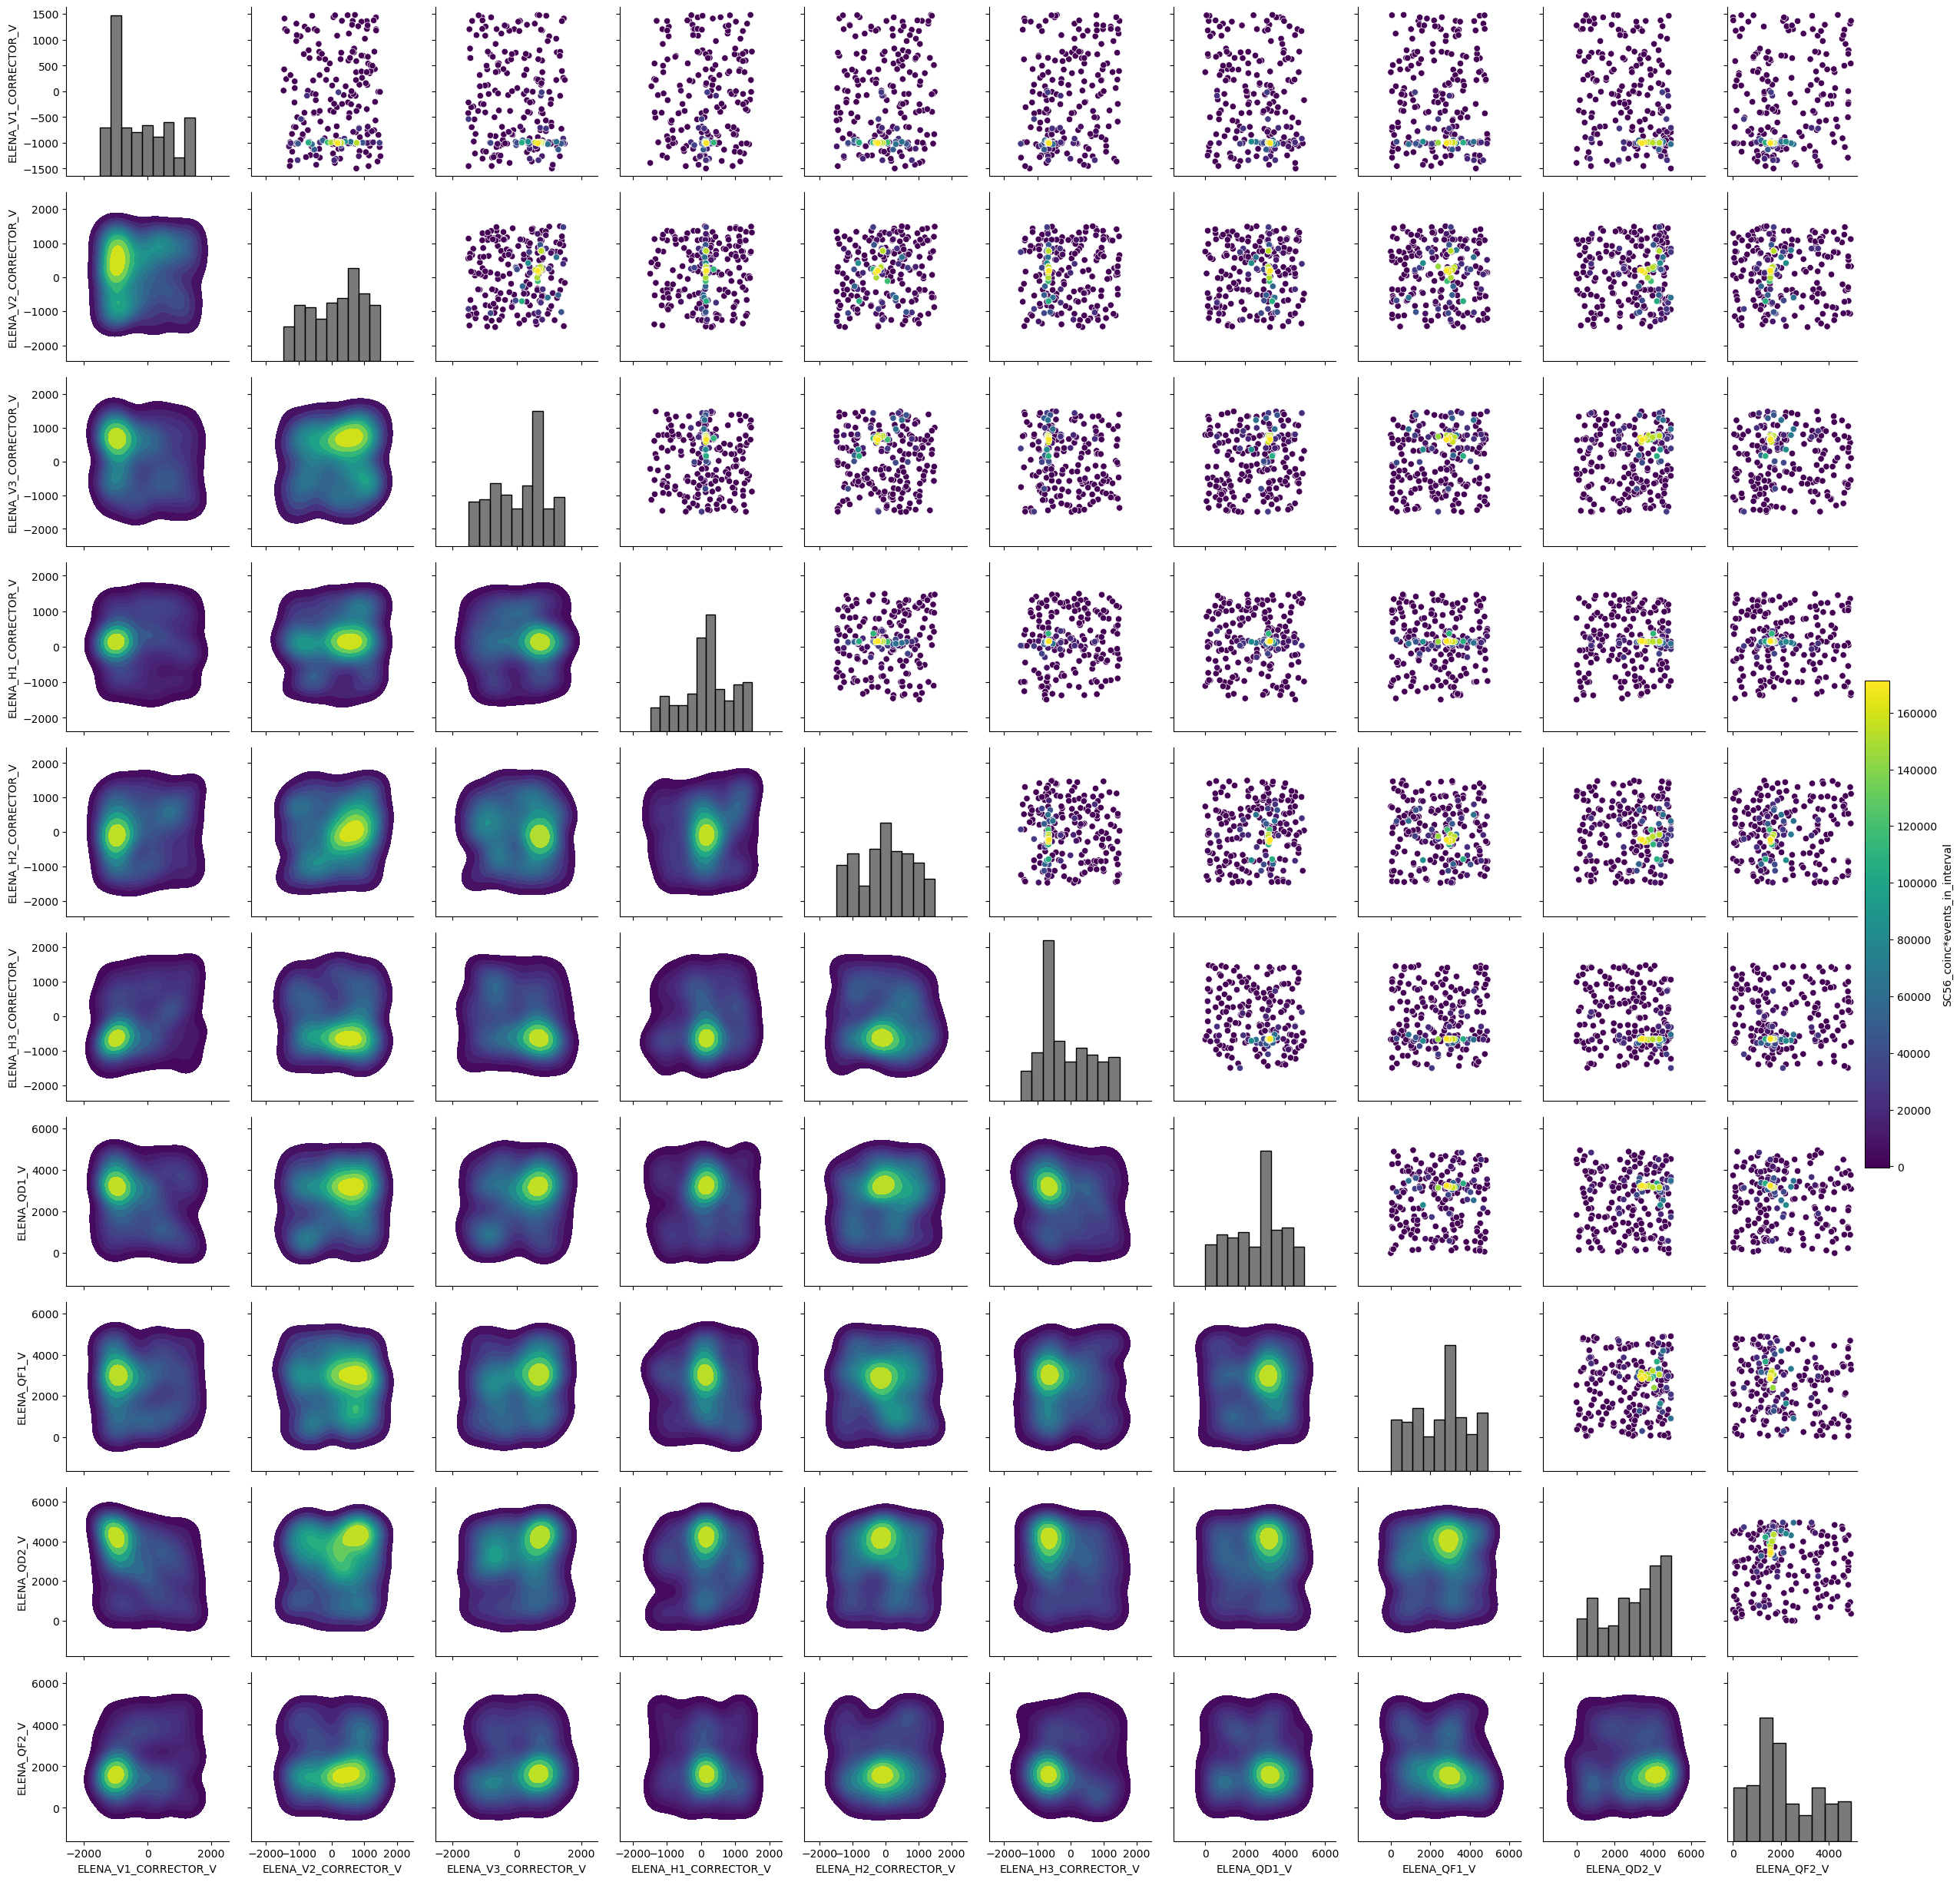

In [117]:
g = sns.PairGrid(optimiser_history.select(pl.all().exclude("iteration")),palette=palette,hue='Target')
g.map_diag(sns.histplot, hue=None, color=".3",palette=None,legend=False)
g.map_lower(sns.kdeplot, zorder=0, levels=15,thresh=0.05,fill=True,  cbar=False, cmap=palette,hue=None,palette=None,legend=False)
g.map_upper(sns.scatterplot,c=pl.Series(optimiser_history.select("Target")).to_list(),cmap=palette,palette=None,legend=False)

fig = g.figure
plt.colorbar(sm,ax=g.axes[:, -1],label="SC56_coinc*events_in_interval")
# fig.tight_layout()